# Showing of basics of shaped rigid bodies

The Multiscale Polymer Toolkit supports a variety of bounded shapes, which are used to specify how Primitives look in space

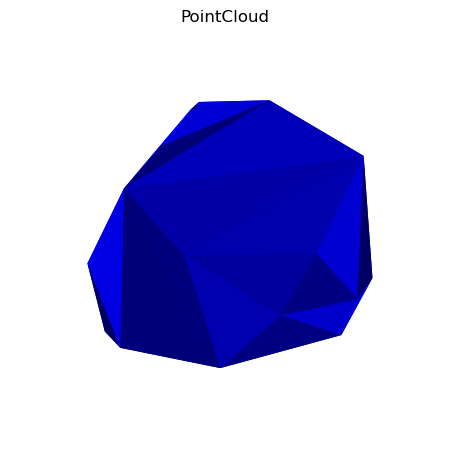

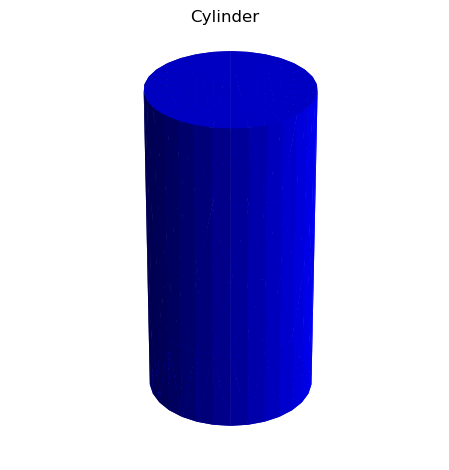

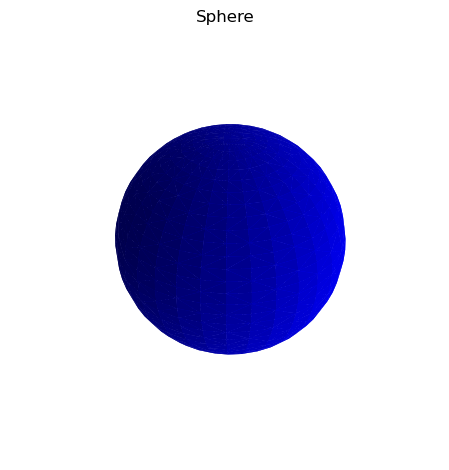

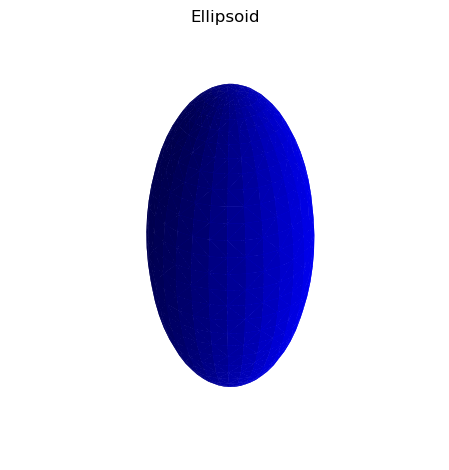

In [1]:
import numpy as np
from mupt.geometry.shapes import (
    BoundedShape,
    visualize_shape,
    Sphere, Ellipsoid, PointCloud, Cylinder,
)
# %matplotlib ipympl

# these are all the supported types of BoundedShape currently in MuPT
shapes : list[BoundedShape] = [
    PointCloud(np.random.rand(40,3)),
    Cylinder(1, 4),
    Sphere(1),
    Ellipsoid.from_components(1, 1, 2),
]

for shape in shapes:
    ax = visualize_shape(shape, grid=False, color='b')

Shapes can be rigidly transformed, rotated and translated however one likes in space

1.0


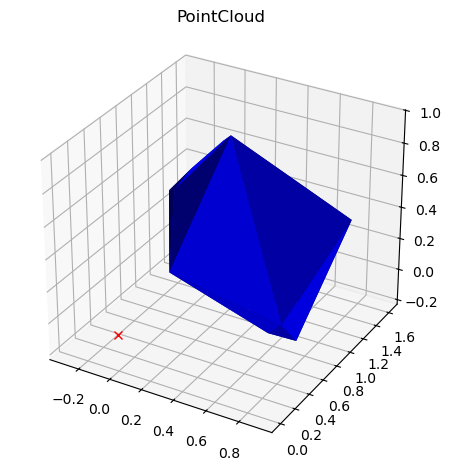

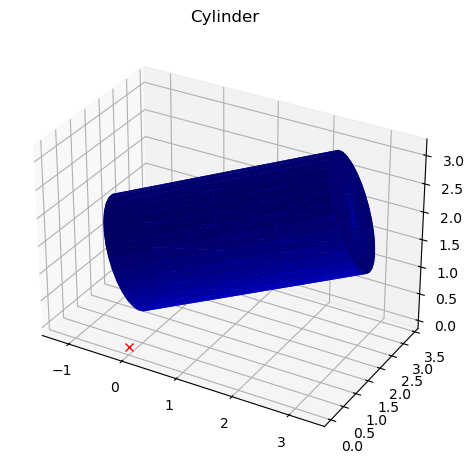

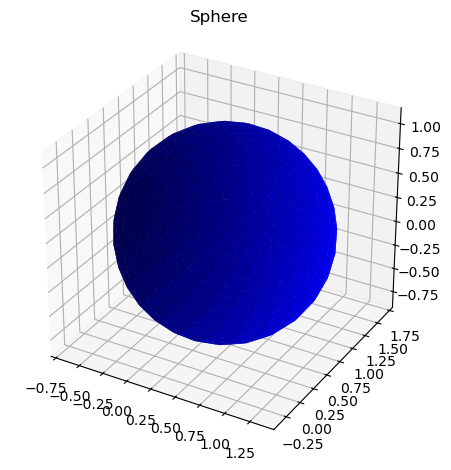

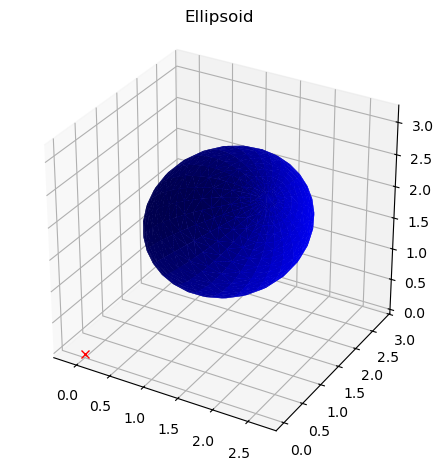

In [2]:
from mupt.geometry.transforms.rigid import random_rigid_transformation

for shape in shapes:
    shape.rigidly_transform(
        random_rigid_transformation(translation_bound=2.0)
    )
    ax = visualize_shape(shape, grid=True, color='b')
    ax.plot(0, 0, 0, 'rx') # show the origin for reference

Shapes also support uniform scaling, in a manner which respects accumulated rigid transformations

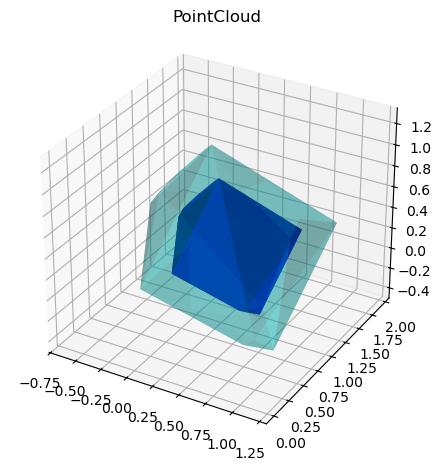

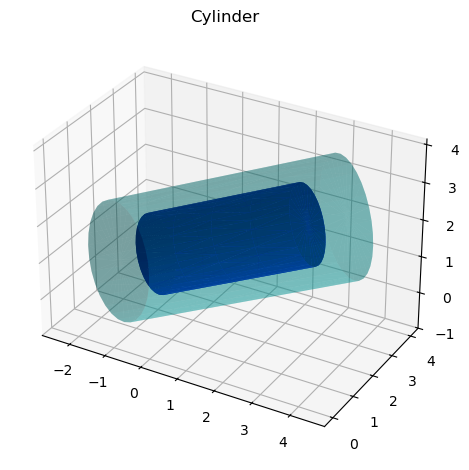

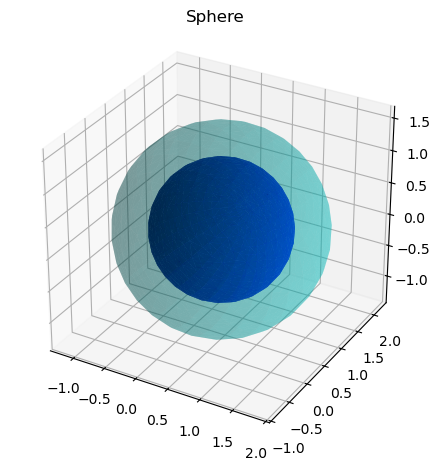

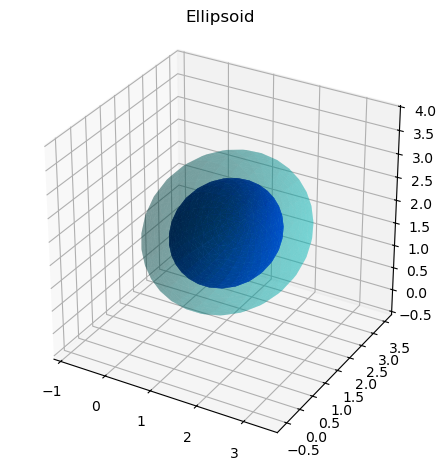

In [3]:
for shape in shapes:
    ax = visualize_shape(shape, grid=True, color='b', alpha=1.0) # original
    ax = visualize_shape(shape.scaled(1.5), ax=ax, color='c', alpha=0.3) # enlarged

### Point Clouds as conformers
Given a molecule, one can natively encode it's atomic positions with PointCloud shapes

[15:35:19] UFFTYPER: Unrecognized atom type: *_ (0)
[15:35:19] UFFTYPER: Unrecognized atom type: *_ (8)


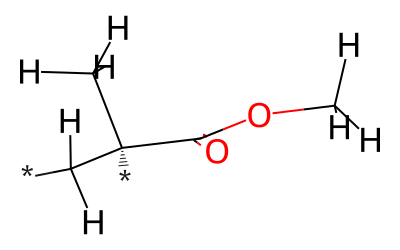

17


In [4]:
from rdkit import Chem
from rdkit.Chem.AllChem import EmbedMolecule

from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.molSize = (400, 250)


smi =  '*[C@](C)(C(=O)OC)C*' # PMMA middle repeat unit
mol = Chem.MolFromSmiles(smi, sanitize=True)
mol = Chem.AddHs(mol)

conf_idx : int = EmbedMolecule(mol)
assert conf_idx != -1
display(mol)
print(mol.GetNumAtoms())

PointCloud(shape=(17, 3))


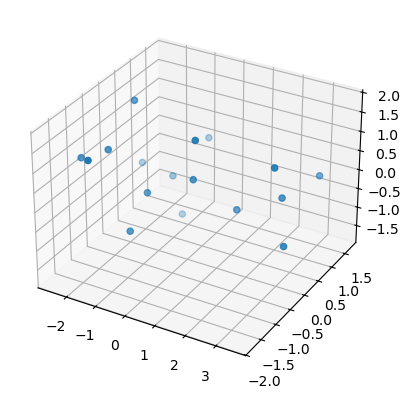

In [5]:
import matplotlib.pyplot as plt


conformer = PointCloud(mol.GetConformer(0).GetPositions())
print(conformer)

fig, ax = plt.subplots(1, 1, subplot_kw={'projection' : '3d'})
_ = ax.scatter(*conformer.positions.T)

## Export Shapes as animated GIFs

1.0


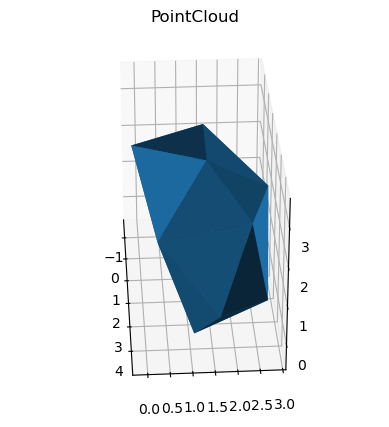

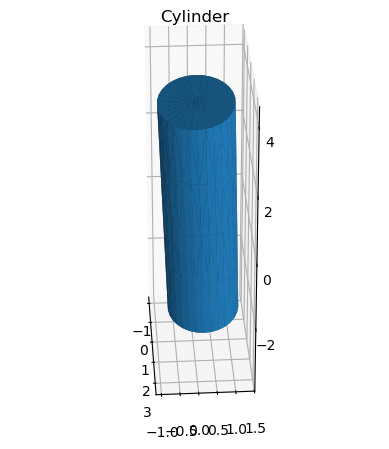

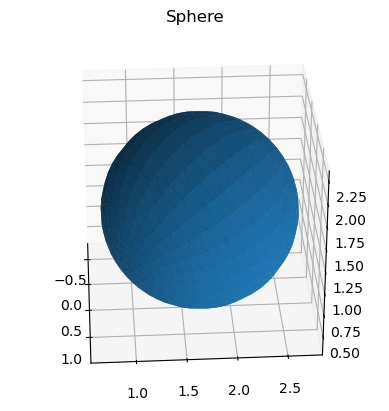

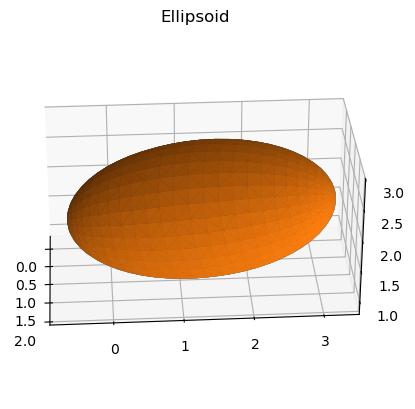

In [6]:
# NBVAL_SKIP
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


shapes_dir = Path('shapes')
shapes_dir.mkdir(parents=True, exist_ok=True)

n_frames : int = 100
loop_time_sec : float = 5
interval = int(loop_time_sec*1000/n_frames) # convert to milliseconds

shapes_animated = [     
    conformer,
    Cylinder.from_radius_and_axis(1, 4*np.ones(3)/np.sqrt(3)),
    Sphere(1),
    Ellipsoid.from_components(1, 1, 2),
]
for shape in shapes_animated:
    shape_name : str = type(shape).__name__.lower()
    shape.rigidly_transform(
        random_rigid_transformation(translation_bound=2.0)
    )

    fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'})
    ax.set_title(shape_name)
    anim = FuncAnimation(
        fig,
        func=lambda i : ax.view_init(azim=(i/n_frames)*360),
        init_func=lambda : visualize_shape(shape, ax=ax),
        frames=n_frames,
        interval=interval,
        blit=False,
    )
    anim.save(shapes_dir / f'{shape_name}.gif')